In [ ]:
#pip install statsmodels pandas numpy mtplotlib seaborn sklearn

In [19]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [3]:
df = pd.read_csv('data/house_prices.csv')

In [22]:
df.dtypes

price              float64
bedrooms             int64
bathrooms          float64
sqft_living          int64
sqft_lot             int64
floors             float64
waterfront           int64
view                 int64
condition            int64
grade                int64
yr_built             int64
zipcode              int64
lat                float64
long               float64
renovated            int64
basement             int64
log_price          float64
log_sqft_living    float64
lat_c              float64
long_c             float64
age                  int64
dtype: object

In [4]:
df['log_price'] = np.log(df['price'])
df['log_sqft_living'] = np.log(df['sqft_living'])
df['lat_c'] = df['lat'] - df['lat'].mean()
df['long_c'] = df['long'] - df['long'].mean()
df['age'] = 2015 - df['yr_built']

In [22]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

In [23]:
model = smf.ols('log_price ~ bathrooms + log_sqft_living + C(zipcode) + floors + waterfront + view + condition + grade + age + renovated + basement', data = train) 
model = model.fit(cov_type='HC3')
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     1302.
Date:                Fri, 15 May 2026   Prob (F-statistic):               0.00
Time:                        21:43:07   Log-Likelihood:                 4433.1
No. Observations:               17290   AIC:                            -8706.
Df Residuals:                   17210   BIC:                            -8086.
Df Model:                          79                                         
Covariance Type:                  HC3                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               7.8701      0.049    162.154      0.000       7.775       7.965
C(zipcode)[T.98002]    -0.0297      0.016     -1.813      0.070      -0.062       0.002
C(zipcode)[T.98003]    -0.0081      0.015     -0.534      0.593      -0.038       0.022
C(zipcode)[T.98004]     1.1272      0.017     64.870      0.000       1.093       1.161
C(zipcode)[T.98005]     0.7404      0.019     40.014      0.000       0.704       0.777
C(zipcode)[T.98006]     0.6543      0.015     44.081      0.000       0.625       0.683
C(zipcode)[T.98007]     0.6302      0.018     35.733      0.000       0.596       0.665
C(zipcode)[T.98008]     0.6240      0.015     42.048      0.000       0.595       0.653
C(zipcode)[T.98010]     0.3087      0.034      8.954      0.000       0.241       0.376
C(zipcode)[T.98011]     0.4534      0.015     29.801      0.000       0.424       0.483
C(zipcode)[T.98014]     0.3924      0.032     12.084      0.000       0.329       0.456
C(zipcode)[T.98019]     0.3711      0.017     21.412      0.000       0.337       0.405
C(zipcode)[T.98022]     0.0774      0.019      4.087      0.000       0.040       0.115
C(zipcode)[T.98023]    -0.0374      0.014     -2.740      0.006      -0.064      -0.011
C(zipcode)[T.98024]     0.5316      0.029     18.338      0.000       0.475       0.588
C(zipcode)[T.98027]     0.5439      0.015     36.183      0.000       0.514       0.573
C(zipcode)[T.98028]     0.4135      0.015     27.868      0.000       0.384       0.443
C(zipcode)[T.98029]     0.5889      0.013     45.146      0.000       0.563       0.614
C(zipcode)[T.98030]     0.0439      0.015      2.935      0.003       0.015       0.073
C(zipcode)[T.98031]     0.0736      0.015      4.888      0.000       0.044       0.103
C(zipcode)[T.98032]    -0.0427      0.022     -1.911      0.056      -0.087       0.001
C(zipcode)[T.98033]     0.7795      0.016     47.537      0.000       0.747       0.812
C(zipcode)[T.98034]     0.5334      0.014     38.991      0.000       0.507       0.560
C(zipcode)[T.98038]     0.1905      0.014     14.101      0.000       0.164       0.217
C(zipcode)[T.98039]     1.3312      0.027     49.988      0.000       1.279       1.383
C(zipcode)[T.98040]     0.8845      0.017     52.501      0.000       0.852       0.918
C(zipcode)[T.98042]     0.0707      0.014      5.231      0.000       0.044       0.097
C(zipcode)[T.98045]     0.3592      0.018     19.612      0.000       0.323       0.395
C(zipcode)[T.98052]     0.6432      0.013     49.296      0.000       0.618       0.669
C(zipcode)[T.98053]     0.6253      0.014     44.725      0.000       0.598       0.653
C(zipcode)[T.98055]     0.1369      0.018      7.643      0.000       0.102       0.172
C(zipcode)[T.98056]     0.3197      0.016     20.391      0.000       0.289       0.350
C(z

In [25]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(test)
y_true = test['log_price']

print(f"R^2 train: {model.rsquared:.4f}")
print(f"R^2 test:  {r2_score(y_true, y_pred):.4f}")
print(f"RMSE test (log): {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")

R^2 train: 0.8727
R^2 test:  0.8750
RMSE test (log): 0.1888


<Axes: >

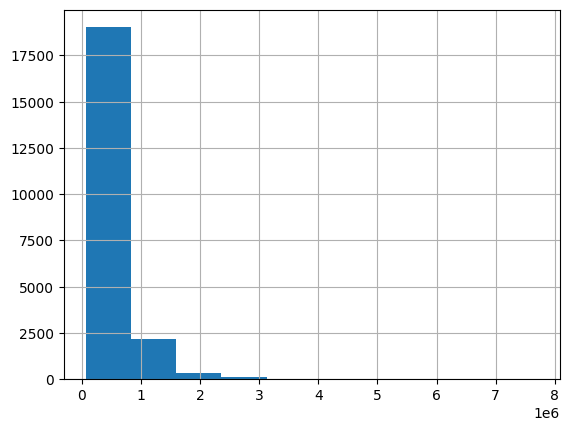

In [6]:
df.price.hist()

<Axes: >

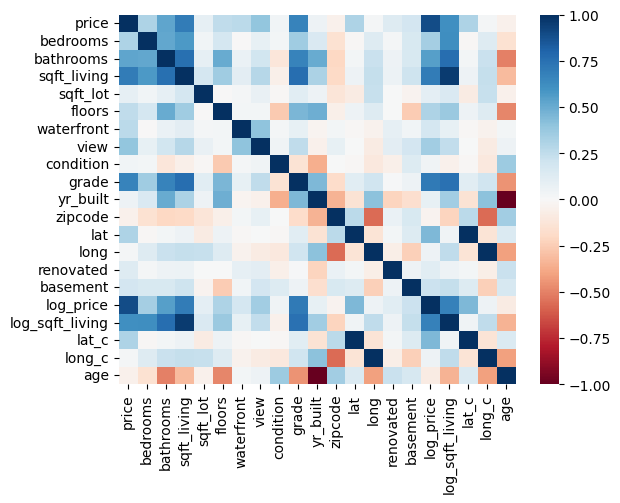

In [7]:
cor_table = df.select_dtypes(exclude = "object").corr()
sns.heatmap(cor_table, vmin = -1, vmax = 1, center =0,cmap = "RdBu")

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

numeric_features = ['log_sqft_living', 'bathrooms', 'bedrooms', 'grade', 
                    'condition', 'view', 'waterfront', 'age', 
                    'renovated', 'basement', 'floors']

X = add_constant(df[numeric_features])

vif = pd.DataFrame({
    'feature': X.columns[1:],
    'VIF': [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif)

            feature       VIF
0   log_sqft_living  4.234046
1         bathrooms  3.282482
3             grade  2.761446
7               age  1.985856
2          bedrooms  1.769971
10           floors  1.742702
5              view  1.346575
9          basement  1.333678
4         condition  1.218446
6        waterfront  1.201075
8         renovated  1.142529


In [26]:
import statsmodels.stats.api as sms
model_resid = model.resid
model_fittedvalues = model.fittedvalues
model_exog = model.model.exog

In [27]:
from statsmodels.compat import lzip
names = ['Lagrange multiplier statistic', 'p-value',
        'f-value', 'f p-value']
test = sms.het_breuschpagan(model_resid, model_exog)
lzip(names, test)

#W tym wypadku heteroskedastyczność nie powinna stanowić problemu, bo w modelu zastosowano odporne błędy standardowe HC3

[('Lagrange multiplier statistic', np.float64(1147.1819279962904)),
 ('p-value', np.float64(4.1328889880635335e-189)),
 ('f-value', np.float64(15.4812749363679)),
 ('f p-value', np.float64(1.3149191864383105e-196))]

<Axes: xlabel='None', ylabel='None'>

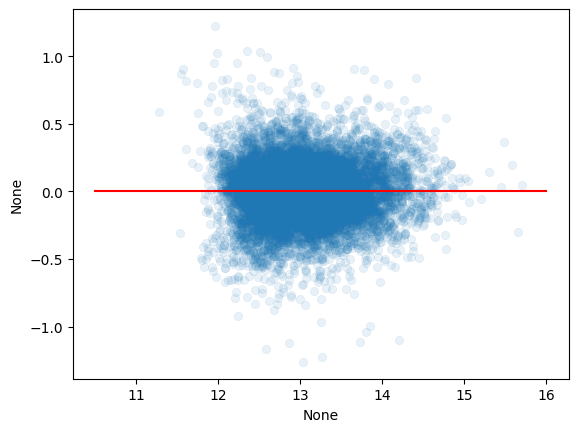

In [28]:
sns.scatterplot(x = model_fittedvalues, y = model_resid, alpha=0.1, edgecolor=None)
sns.lineplot(x = [10.5, 16], y = [0, 0], color = 'red')